# Chapter 05: Smooth Length Structures

## Source Span

*A Course in Metric Geometry*, Chapter 5, printed pages 135-208 and PDF pages 150-223. The source was used for section order, terminology, theorem orientation, and page spans only; the prose, examples, code, and artifacts here are original.

## Chapter Question

How does a smooth rule for measuring tangent vectors become a metric space, and what changes when the rule measures only selected directions, or when volume is required to respect metric monotonicity?

Chapter 5 is the bridge between the earlier abstract theory of length spaces and the later comparison chapters. A Riemannian metric starts as a smoothly varying positive quadratic form on tangent planes, but it becomes a length space only after curves are integrated. The exponential map then turns initial velocity data into geodesic rays and normal coordinate grids. Hyperbolic geometry supplies a model where the metric is smooth, conformal, and visually deceptive: Euclidean circles may be hyperbolic lines, and Euclidean area is the wrong quantity. Sub-Riemannian geometry changes the rules again by allowing only horizontal directions; brackets and commutator loops recover missing motion. The volume sections ask which measure is forced by the metric, and the Besikovitch inequality shows how very limited distance data across a cube already implies a volume lower bound.


## Source Coverage Map

| Source section | Computational translation | Artifact or check |
| --- | --- | --- |
| 5.1 Riemannian length structures | Metric coefficients `E,F,G`, tangent-unit ellipses, curve length integration | `metric-tensor-length-field.png`, `metric-length-checks.json` |
| 5.2 Exponential map | Initial velocities, geodesic rays, normal wavefronts, Gauss-lemma orthogonality | `exponential-map-normal-coordinates.png`, `exponential-map-checks.json` |
| 5.3 Hyperbolic plane | Poincare disk geodesics, horocycles, distance formula, isometry invariance | `hyperbolic-poincare-lab.html`, `hyperbolic-model-checks.json` |
| 5.4 Sub-Riemannian structures | Horizontal vector fields, bracket-generated vertical motion, ball-box scaling | `sub-riemannian-ball-box.png`, `sub-riemannian-checks.json` |
| 5.5 Riemannian and Finsler volumes | Riemannian density, norm unit balls, several Finsler volume densities | `volume-comparison.png`, `finsler-volume-table.csv`, `volume-comparison-checks.json` |
| 5.6 Besikovitch inequality | Face distances, nonexpanding distance map, degree/surjectivity proof scaffold | `besikovitch-cube-map.png`, `besikovitch-proof-dependency.png`, `besikovitch-checks.json` |

## Library Routing

Matplotlib is used for durable static metric diagrams and proof overlays. Plotly is used for the hyperbolic lab because the Poincare disk benefits from browser inspection. NetworkX is used where the geometry is a proof dependency chain rather than a single picture. Pandas records the Finsler volume table, and Pillow verifies that generated images are nonblank.

## Visual Storyboard

The ordered storyboard is: metric tensor and length field, exponential-map normal coordinates, Poincare disk HTML lab, sub-Riemannian ball-box model, Riemannian/Finsler volume comparison, and Besikovitch proof map. The notebook writes this plan to `visual-storyboard.json` and the source coverage contract to `source-coverage.json`.


In [1]:
from pathlib import Path
import json, math
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Rectangle
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import networkx as nx
import plotly.graph_objects as go
from IPython.display import HTML, Image, display
from PIL import Image as PILImage, ImageStat

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / 'AGENTS.md').exists() and (candidate / 'source_map.json').exists() and (candidate / 'artifacts').exists():
        BOOK_ROOT = candidate
        break

ARTIFACT_DIR = BOOK_ROOT / 'artifacts' / 'chapter-05'
FIG_DIR = ARTIFACT_DIR / 'figures'
HTML_DIR = ARTIFACT_DIR / 'html'
CHECK_DIR = ARTIFACT_DIR / 'checks'
TABLE_DIR = ARTIFACT_DIR / 'tables'
for directory in [FIG_DIR, HTML_DIR, CHECK_DIR, TABLE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

SOURCE_SPAN = {
    'chapter': '05 Smooth Length Structures',
    'printed_pages': '135-208',
    'pdf_pages': '150-223',
    'sections': {
        '5.1': 'Riemannian Length Structures',
        '5.2': 'Exponential Map',
        '5.3': 'Hyperbolic Plane',
        '5.4': 'Sub-Riemannian Metric Structures',
        '5.5': 'Riemannian and Finsler Volumes',
        '5.6': 'Besikovitch Inequality',
    },
    'source_use': 'orientation, terminology, section order, and theorem targets only',
}

def rel(path):
    return str(Path(path).relative_to(BOOK_ROOT)).replace('\\', '/')

def write_json(path, data):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2, sort_keys=True), encoding='utf-8')
    return path

def save_matplotlib(fig, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=170, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    return path

def display_artifact(path, width=780):
    path = Path(path)
    if path.suffix.lower() == '.png':
        display(Image(filename=str(path), width=width))
    elif path.suffix.lower() == '.html':
        display(HTML(f'<a href="{rel(path)}" target="_blank">Open interactive artifact: {path.name}</a>'))
    else:
        display(HTML(f'<code>{rel(path)}</code>'))

def image_stats(path):
    with PILImage.open(path) as im:
        stat = ImageStat.Stat(im.convert('L'))
        return {'size': list(im.size), 'mean': float(stat.mean[0]), 'stddev': float(stat.stddev[0])}


## 1. Riemannian Length Structures: Local Norms Before Global Distances

A Riemannian metric in coordinates is a symmetric matrix with coefficients `E,F,G`. It is valid where `E > 0`, `G > 0`, and `EG-F^2 > 0`. Once those inequalities hold, the length of a velocity vector `v=(xdot,ydot)` is `sqrt(v.T @ g @ v)`, and the length of a curve is the integral of that quantity.

The figure below draws tangent-unit ellipses. These are not balls in the ambient Euclidean drawing; they are the set of tangent vectors with Riemannian length one at each base point. The black curve is a sample path whose Riemannian length is compared with its Euclidean length. This is the main translation from section 5.1: a smooth tangent-plane rule becomes a length structure only after we integrate along curves.


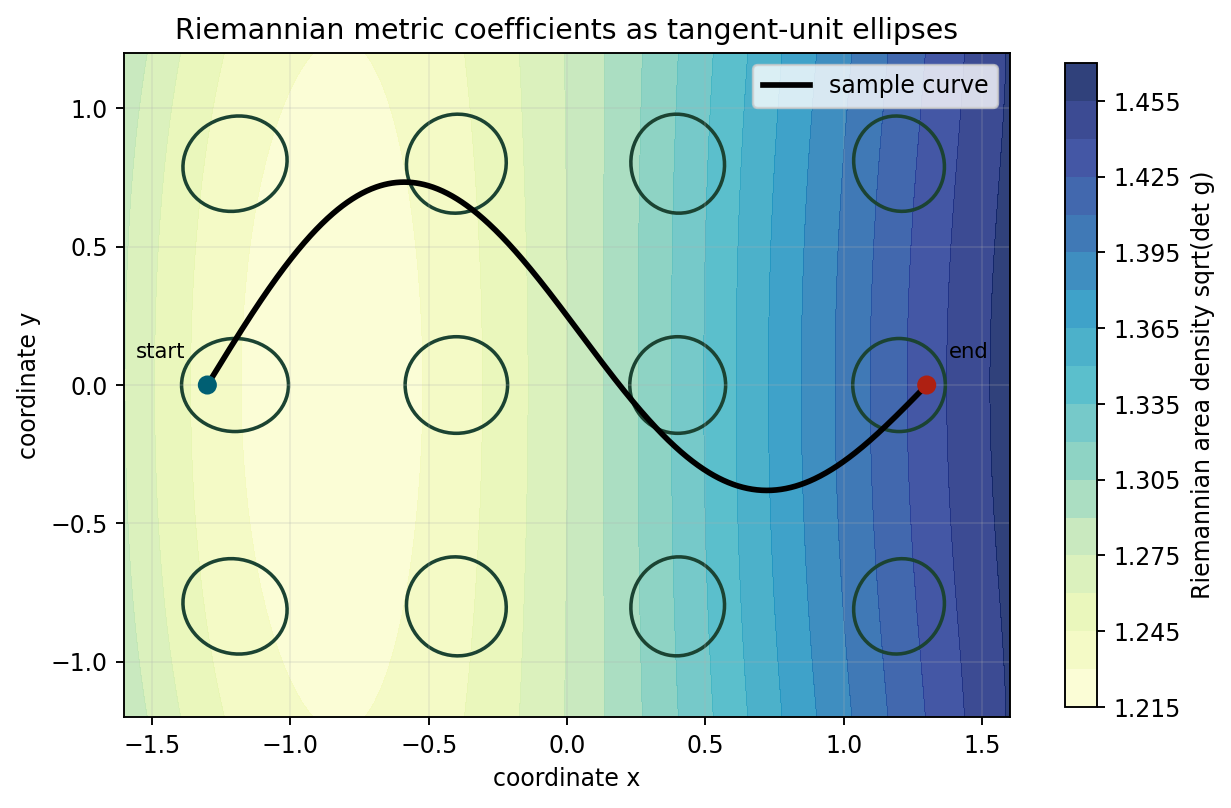

,artifact,euclidean_length,length_ratio,minimum_metric_determinant_on_grid,minimum_metric_eigenvalue_on_grid,positive_definite_on_grid,riemannian_length
0,artifacts/chapter-05/figures/metric-tensor-len...,3.545279,1.137846,1.488994,1.070017,True,4.033983


In [2]:
def metric_matrix(x, y):
    E = 1.25 + 0.18 * np.sin(1.2 * x) + 0.10 * y * y
    F = 0.18 * np.sin(x * y / 1.8)
    Gcoef = 1.05 + 0.25 * np.cos(0.9 * y) + 0.08 * x * x
    return np.array([[E, F], [F, Gcoef]], dtype=float)

def curve(t):
    return np.array([2.6 * t - 1.3, 0.55 * np.sin(2 * np.pi * t) + 0.25 * np.sin(np.pi * t)])

def curve_derivative(t):
    return np.array([2.6 + 0 * t, 0.55 * 2 * np.pi * np.cos(2 * np.pi * t) + 0.25 * np.pi * np.cos(np.pi * t)])

ts = np.linspace(0, 1, 900)
pts = np.array([curve(t) for t in ts])
vels = np.array([curve_derivative(t) for t in ts])
riem_speed = np.array([math.sqrt(v @ metric_matrix(p[0], p[1]) @ v) for p, v in zip(pts, vels)])
euclid_speed = np.linalg.norm(vels, axis=1)
riem_length = float(np.trapezoid(riem_speed, ts))
euclid_length = float(np.trapezoid(euclid_speed, ts))

fig, ax = plt.subplots(figsize=(8.4, 6.0))
xx = np.linspace(-1.6, 1.6, 150)
yy = np.linspace(-1.2, 1.2, 130)
X, Y = np.meshgrid(xx, yy)
density = np.zeros_like(X)
min_eig = math.inf
min_det = math.inf
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        M = metric_matrix(X[i, j], Y[i, j])
        density[i, j] = math.sqrt(np.linalg.det(M))
        eigs = np.linalg.eigvalsh(M)
        min_eig = min(min_eig, float(eigs[0]))
        min_det = min(min_det, float(np.linalg.det(M)))
cont = ax.contourf(X, Y, density, levels=16, cmap='YlGnBu', alpha=0.86)
fig.colorbar(cont, ax=ax, shrink=0.82, label='Riemannian area density sqrt(det g)')

for x0 in np.linspace(-1.2, 1.2, 4):
    for y0 in np.linspace(-0.8, 0.8, 3):
        M = metric_matrix(x0, y0)
        vals, vecs = np.linalg.eigh(M)
        axes = 0.20 / np.sqrt(vals)
        angle = math.degrees(math.atan2(vecs[1, 0], vecs[0, 0]))
        ax.add_patch(Ellipse((x0, y0), 2*axes[0], 2*axes[1], angle=angle, facecolor='none', edgecolor='#1b4332', lw=1.5))

ax.plot(pts[:, 0], pts[:, 1], color='black', lw=2.4, label='sample curve')
ax.scatter([pts[0,0], pts[-1,0]], [pts[0,1], pts[-1,1]], color=['#005f73', '#ae2012'], s=50, zorder=5)
ax.text(pts[0,0]-0.08, pts[0,1]+0.10, 'start', ha='right', fontsize=9)
ax.text(pts[-1,0]+0.08, pts[-1,1]+0.10, 'end', ha='left', fontsize=9)
ax.set_title('Riemannian metric coefficients as tangent-unit ellipses')
ax.set_xlabel('coordinate x')
ax.set_ylabel('coordinate y')
ax.set_aspect('equal', adjustable='box')
ax.grid(alpha=0.2)
ax.legend(loc='upper right')
fig_path = save_matplotlib(fig, FIG_DIR / 'metric-tensor-length-field.png')
check_path = write_json(CHECK_DIR / 'metric-length-checks.json', {
    'artifact': rel(fig_path),
    'riemannian_length': riem_length,
    'euclidean_length': euclid_length,
    'length_ratio': riem_length / euclid_length,
    'minimum_metric_eigenvalue_on_grid': min_eig,
    'minimum_metric_determinant_on_grid': min_det,
    'positive_definite_on_grid': bool(min_eig > 0 and min_det > 0),
})
display_artifact(fig_path)
pd.DataFrame([json.loads(check_path.read_text(encoding='utf-8'))])


## 2. Exponential Map: Velocity Data Becomes Coordinates

The exponential map at a point sends a tangent vector to the endpoint reached by following the geodesic with that initial velocity for the matching time. The source uses this to organize normal coordinates and the Gauss lemma: radial geodesics and wavefronts are orthogonal in those coordinates.

The next model uses the unit sphere because its exponential map has a closed form. At the north pole `p`, a tangent vector of norm `r` and angle `theta` maps to `(sin r cos theta, sin r sin theta, cos r)`. The picture is not pretending the chapter is about spheres only. It is a clean laboratory for the general mechanism: initial velocities sweep out geodesic rays, while fixed-length vectors sweep out geodesic circles.


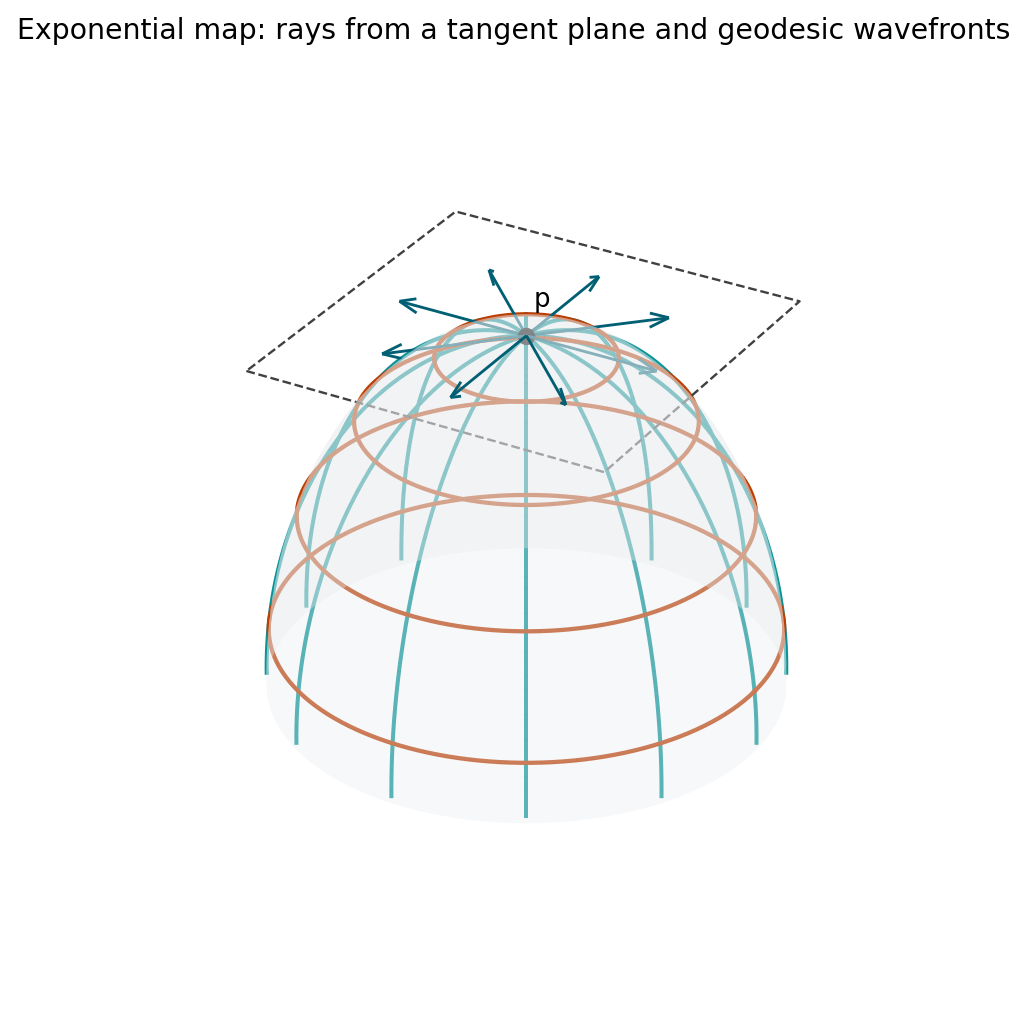

{'artifact': 'artifacts/chapter-05/figures/exponential-map-normal-coordinates.png',
 'max_endpoint_unit_sphere_error': 0.0,
 'max_radial_angular_dot_product': 2.7755575615628914e-17,
 'model': 'unit sphere exponential map at north pole',
 'normal_coordinate_message': 'radial geodesics and fixed-radius wavefronts are orthogonal in this model'}

In [3]:
def sphere_exp(r, theta):
    return np.array([np.sin(r) * np.cos(theta), np.sin(r) * np.sin(theta), np.cos(r)])

rays = np.linspace(0.0, 1.55, 100)
thetas = np.linspace(0, 2*np.pi, 160)
fig = plt.figure(figsize=(9.0, 7.2))
ax = fig.add_subplot(111, projection='3d')
u = np.linspace(0, np.pi/2, 48)
v = np.linspace(0, 2*np.pi, 96)
U, Vv = np.meshgrid(u, v)
ax.plot_surface(np.sin(U)*np.cos(Vv), np.sin(U)*np.sin(Vv), np.cos(U), color='#e9ecef', alpha=0.36, linewidth=0, shade=False)
for theta in np.linspace(0, 2*np.pi, 12, endpoint=False):
    P = np.array([sphere_exp(r, theta) for r in rays])
    ax.plot(P[:,0], P[:,1], P[:,2], color='#0a9396', lw=1.7)
for r in [0.35, 0.70, 1.05, 1.40]:
    C = np.array([sphere_exp(r, theta) for theta in thetas])
    ax.plot(C[:,0], C[:,1], C[:,2], color='#bb3e03', lw=1.8)
plane = np.array([[-0.75,-0.75,1.0],[0.75,-0.75,1.0],[0.75,0.75,1.0],[-0.75,0.75,1.0],[-0.75,-0.75,1.0]])
ax.plot(plane[:,0], plane[:,1], plane[:,2], color='0.25', lw=1.0, ls='--')
for theta in np.linspace(0, 2*np.pi, 8, endpoint=False):
    ax.quiver(0, 0, 1, 0.55*np.cos(theta), 0.55*np.sin(theta), 0, color='#005f73', arrow_length_ratio=0.14, lw=1.2)
ax.scatter([0], [0], [1], color='black', s=40)
ax.text(0.02, 0.02, 1.08, 'p', fontsize=11)
ax.set_title('Exponential map: rays from a tangent plane and geodesic wavefronts')
ax.set_box_aspect((1,1,0.75))
ax.set_axis_off()
fig_path = save_matplotlib(fig, FIG_DIR / 'exponential-map-normal-coordinates.png')

samples = []
for r in np.linspace(0.2, 1.45, 6):
    for theta in np.linspace(0, 2*np.pi, 10, endpoint=False):
        dr = np.array([np.cos(r)*np.cos(theta), np.cos(r)*np.sin(theta), -np.sin(r)])
        dtheta = np.array([-np.sin(r)*np.sin(theta), np.sin(r)*np.cos(theta), 0.0])
        samples.append(abs(float(np.dot(dr, dtheta))))
endpoint_norms = [float(np.linalg.norm(sphere_exp(r, theta))) for r in np.linspace(0,1.5,8) for theta in np.linspace(0,2*np.pi,8,endpoint=False)]
check_path = write_json(CHECK_DIR / 'exponential-map-checks.json', {
    'artifact': rel(fig_path),
    'model': 'unit sphere exponential map at north pole',
    'max_radial_angular_dot_product': max(samples),
    'max_endpoint_unit_sphere_error': max(abs(n - 1.0) for n in endpoint_norms),
    'normal_coordinate_message': 'radial geodesics and fixed-radius wavefronts are orthogonal in this model',
})
display_artifact(fig_path)
json.loads(check_path.read_text(encoding='utf-8'))


## 3. Hyperbolic Plane: A Conformal Model With Non-Euclidean Meaning

The Poincare disk is a useful warning label. It is drawn inside a Euclidean unit disk, and it preserves angles, but it does not preserve Euclidean lengths or areas. Hyperbolic lines are Euclidean diameters or arcs of circles orthogonal to the boundary. Horocycles are limiting wavefronts tangent to the ideal boundary. Distances are computed by the hyperbolic formula, not by the length a ruler sees on the screen.

The HTML artifact gives a small inspection lab: several disk geodesics, horocycles tangent to one boundary point, and radial hyperbolic circles. The check applies a disk isometry and verifies that the distance formula is invariant up to floating-point tolerance.


In [4]:
def disk_distance(z, w):
    z = complex(z); w = complex(w)
    val = 1 + 2 * abs(z-w)**2 / ((1-abs(z)**2) * (1-abs(w)**2))
    return float(np.arccosh(max(1.0, val)))

def disk_isometry(z, a):
    z = complex(z); a = complex(a)
    return (z - a) / (1 - np.conj(a) * z)

def geodesic_arc_from_angles(alpha, beta, n=180):
    z1 = np.array([np.cos(alpha), np.sin(alpha)])
    z2 = np.array([np.cos(beta), np.sin(beta)])
    center = np.linalg.solve(np.vstack([z1, z2]), np.ones(2))
    radius = math.sqrt(np.dot(center, center) - 1)
    a1 = math.atan2(z1[1]-center[1], z1[0]-center[0])
    a2 = math.atan2(z2[1]-center[1], z2[0]-center[0])
    candidates = []
    for shift in [-2*np.pi, 0, 2*np.pi]:
        angles = np.linspace(a1, a2 + shift, n)
        pts = center[:,None] + radius * np.vstack([np.cos(angles), np.sin(angles)])
        candidates.append((np.mean(np.sum(pts*pts, axis=0) < 1.0001), pts))
    pts = max(candidates, key=lambda item: item[0])[1]
    return pts[:, np.sum(pts*pts, axis=0) <= 1.0001]

fig = go.Figure()
theta = np.linspace(0, 2*np.pi, 360)
fig.add_trace(go.Scatter(x=np.cos(theta), y=np.sin(theta), mode='lines', name='ideal boundary', line=dict(color='black', width=2)))
for radius in [0.25, 0.50, 0.72, 0.86]:
    fig.add_trace(go.Scatter(x=radius*np.cos(theta), y=radius*np.sin(theta), mode='lines', name=f'Euclidean circle r={radius}', line=dict(color='rgba(80,80,80,0.25)', width=1)))
for alpha, beta in [(0.15*np.pi, 0.82*np.pi), (1.05*np.pi, 1.65*np.pi), (0.05*np.pi, 1.42*np.pi), (0.50*np.pi, 1.50*np.pi)]:
    if abs((beta-alpha) % (2*np.pi) - np.pi) < 1e-8:
        rr = np.linspace(-0.98, 0.98, 180); x = rr*np.cos(alpha); y = rr*np.sin(alpha)
    else:
        arc = geodesic_arc_from_angles(alpha, beta); x, y = arc[0], arc[1]
    fig.add_trace(go.Scatter(x=x, y=y, mode='lines', name='hyperbolic geodesic', line=dict(color='#0a9396', width=3)))
for c, rad in [((0.72, 0.0), 0.28), ((0.50, 0.0), 0.50), ((0.30, 0.0), 0.70)]:
    fig.add_trace(go.Scatter(x=c[0]+rad*np.cos(theta), y=c[1]+rad*np.sin(theta), mode='lines', name='horocycle family', line=dict(color='#ca6702', width=2, dash='dot')))
pts = [0.15+0.20j, -0.25+0.36j, 0.58-0.18j]
fig.add_trace(go.Scatter(x=[z.real for z in pts], y=[z.imag for z in pts], mode='markers+text', text=['p','q','r'], textposition='top center', name='sample points', marker=dict(color='#ae2012', size=9)))
fig.update_layout(title='Poincare disk lab: geodesics, horocycles, and the ideal boundary', width=820, height=760, xaxis=dict(scaleanchor='y', range=[-1.08,1.08], zeroline=False), yaxis=dict(range=[-1.08,1.08], zeroline=False), template='plotly_white', legend=dict(orientation='h', y=-0.08), annotations=[dict(text='Angles are conformal; Euclidean area and length are not hyperbolic area and length.', x=0, y=-1.16, showarrow=False)])
html_path = HTML_DIR / 'hyperbolic-poincare-lab.html'
fig.write_html(str(html_path), include_plotlyjs='cdn', full_html=True)

z, w, a = 0.20 + 0.31j, -0.36 + 0.18j, 0.22 - 0.15j
d0 = disk_distance(z, w)
d1 = disk_distance(disk_isometry(z, a), disk_isometry(w, a))
radial_rs = np.array([0.1, 0.3, 0.6, 0.85])
radial_formula_errors = [abs(disk_distance(0, r) - 2*np.arctanh(r)) for r in radial_rs]
check_path = write_json(CHECK_DIR / 'hyperbolic-model-checks.json', {
    'artifact': rel(html_path),
    'distance_before_isometry': d0,
    'distance_after_isometry': d1,
    'distance_invariance_error': abs(d0 - d1),
    'max_radial_distance_formula_error': float(max(radial_formula_errors)),
    'inspection_target': 'geodesics are boundary-orthogonal circles while angles remain conformal',
})
display_artifact(html_path)
json.loads(check_path.read_text(encoding='utf-8'))


{'artifact': 'artifacts/chapter-05/html/hyperbolic-poincare-lab.html',
 'distance_after_isometry': 1.2652347130726582,
 'distance_before_isometry': 1.265234713072659,
 'distance_invariance_error': 6.661338147750939e-16,
 'inspection_target': 'geodesics are boundary-orthogonal circles while angles remain conformal',
 'max_radial_distance_formula_error': 4.996003610813204e-16}

## 4. Sub-Riemannian Structures: Missing Directions Can Be Recovered By Brackets

In a Riemannian metric every tangent direction is available. In a sub-Riemannian metric the curve is admissible only when its velocity lies in a prescribed distribution. The model here uses the vector fields `V=(1,0,0)` and `W=(0,1,x)` on `R^3`. Horizontal curves are driven by these two fields.

A vertical vector is not directly allowed, but the commutator loop `flow(V,u)`, `flow(W,v)`, `flow(V,-u)`, `flow(W,-v)` returns to the same `(x,y)` position with vertical displacement `u*v`. This is the computational shadow of the bracket condition behind connectivity and the ball-box theorem.


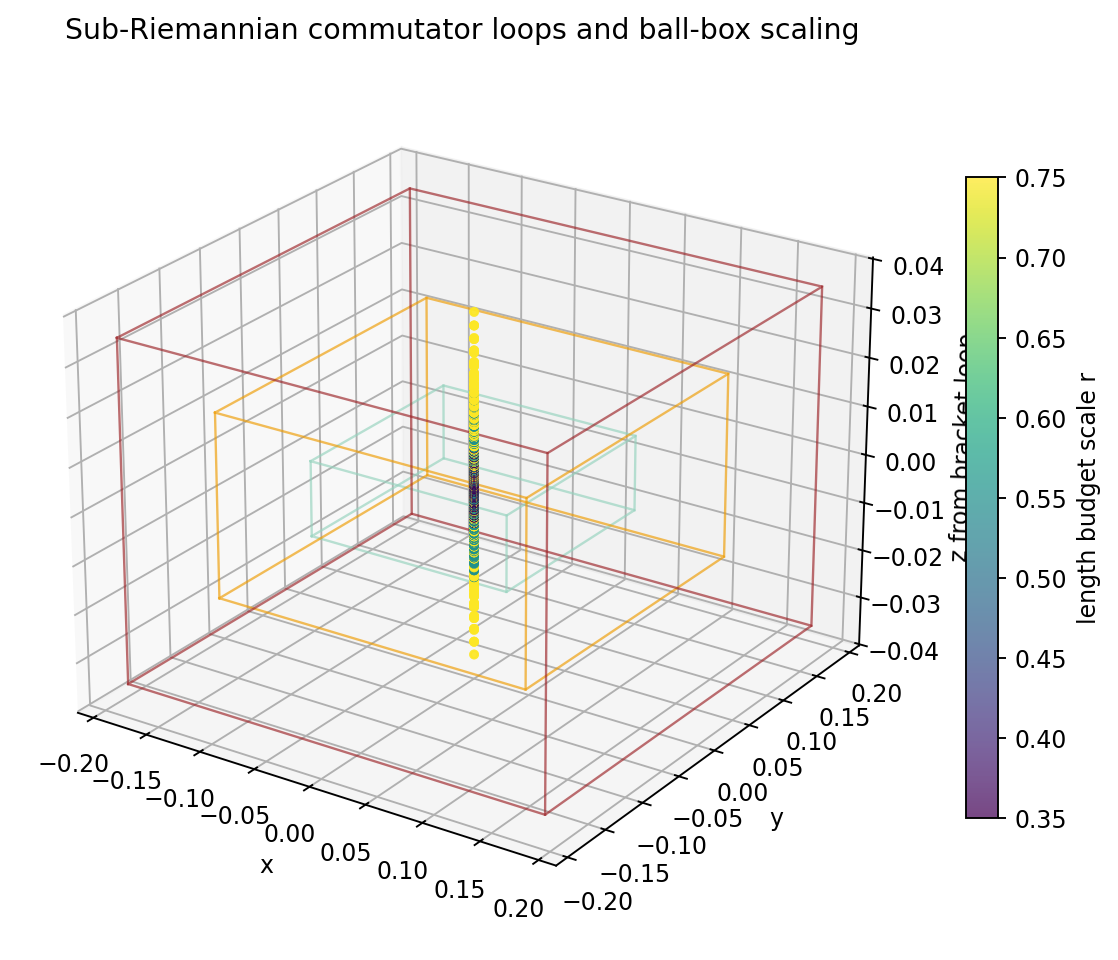

{'artifact': 'artifacts/chapter-05/figures/sub-riemannian-ball-box.png',
 'ball_box_message': 'horizontal scale is order r; bracket direction is order r^2',
 'commutator_endpoint': [0.0, 0.0, 0.06],
 'lie_bracket_at_origin': [0, 0, 1],
 'vector_fields': {'V': [1, 0, 0], 'W': [0, 1, 'x']},
 'vertical_error_against_u_times_v': 0.0}

In [5]:
def flow_V(point, u):
    x, y, z = point
    return np.array([x + u, y, z], dtype=float)

def flow_W(point, v):
    x, y, z = point
    return np.array([x, y + v, z + x * v], dtype=float)

def commutator_endpoint(u, v):
    p = np.array([0.0, 0.0, 0.0])
    for f, a in [(flow_V, u), (flow_W, v), (flow_V, -u), (flow_W, -v)]:
        p = f(p, a)
    return p

rs = [0.35, 0.55, 0.75]
samples = []
for r in rs:
    for u in np.linspace(-r/4, r/4, 27):
        for v in np.linspace(-r/4, r/4, 27):
            p = commutator_endpoint(u, v)
            samples.append([r, p[0], p[1], p[2], u, v])
samples = np.array(samples)

fig = plt.figure(figsize=(9.0, 6.8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(samples[:,1], samples[:,2], samples[:,3], c=samples[:,0], cmap='viridis', s=10, alpha=0.72)
for r, color in [(0.35, '#94d2bd'), (0.55, '#ee9b00'), (0.75, '#9b2226')]:
    hx = r/4; hz = hx*hx
    for sx in [-1, 1]:
        for sy in [-1, 1]:
            ax.plot([sx*hx, sx*hx], [sy*hx, sy*hx], [-hz, hz], color=color, alpha=0.65, lw=1)
    for zlev in [-hz, hz]:
        xs = [-hx, hx, hx, -hx, -hx]; ys = [-hx, -hx, hx, hx, -hx]
        ax.plot(xs, ys, [zlev]*5, color=color, alpha=0.65, lw=1)
ax.set_title('Sub-Riemannian commutator loops and ball-box scaling')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z from bracket loop')
ax.view_init(elev=24, azim=-56)
fig.colorbar(scatter, ax=ax, shrink=0.72, label='length budget scale r')
fig_path = save_matplotlib(fig, FIG_DIR / 'sub-riemannian-ball-box.png')
endpoint = commutator_endpoint(0.2, 0.3)
check_path = write_json(CHECK_DIR / 'sub-riemannian-checks.json', {
    'artifact': rel(fig_path),
    'vector_fields': {'V': [1,0,0], 'W': [0,1,'x']},
    'lie_bracket_at_origin': [0,0,1],
    'commutator_endpoint': endpoint.tolist(),
    'vertical_error_against_u_times_v': abs(float(endpoint[2] - 0.2*0.3)),
    'ball_box_message': 'horizontal scale is order r; bracket direction is order r^2',
})
display_artifact(fig_path)
json.loads(check_path.read_text(encoding='utf-8'))


## 5. Riemannian And Finsler Volumes: One Forced Measure, Several Natural Norm Measures

For Riemannian metrics, volume is forced by Euclidean compatibility and monotonicity. In coordinates it is obtained by integrating `sqrt(det g)`. Finsler metrics are different: once the unit ball is no longer an ellipsoid, several natural volume functionals survive the same broad principles.

The figure below keeps the computation two-dimensional. It compares unit balls for `l1`, `l2`, and `linf` norms and records three densities: Euclidean area of the primal unit ball, a Busemann-style density `pi / area(B)`, and a Holmes-Thompson-style density `area(B*) / pi`, where `B*` is the polar unit ball.


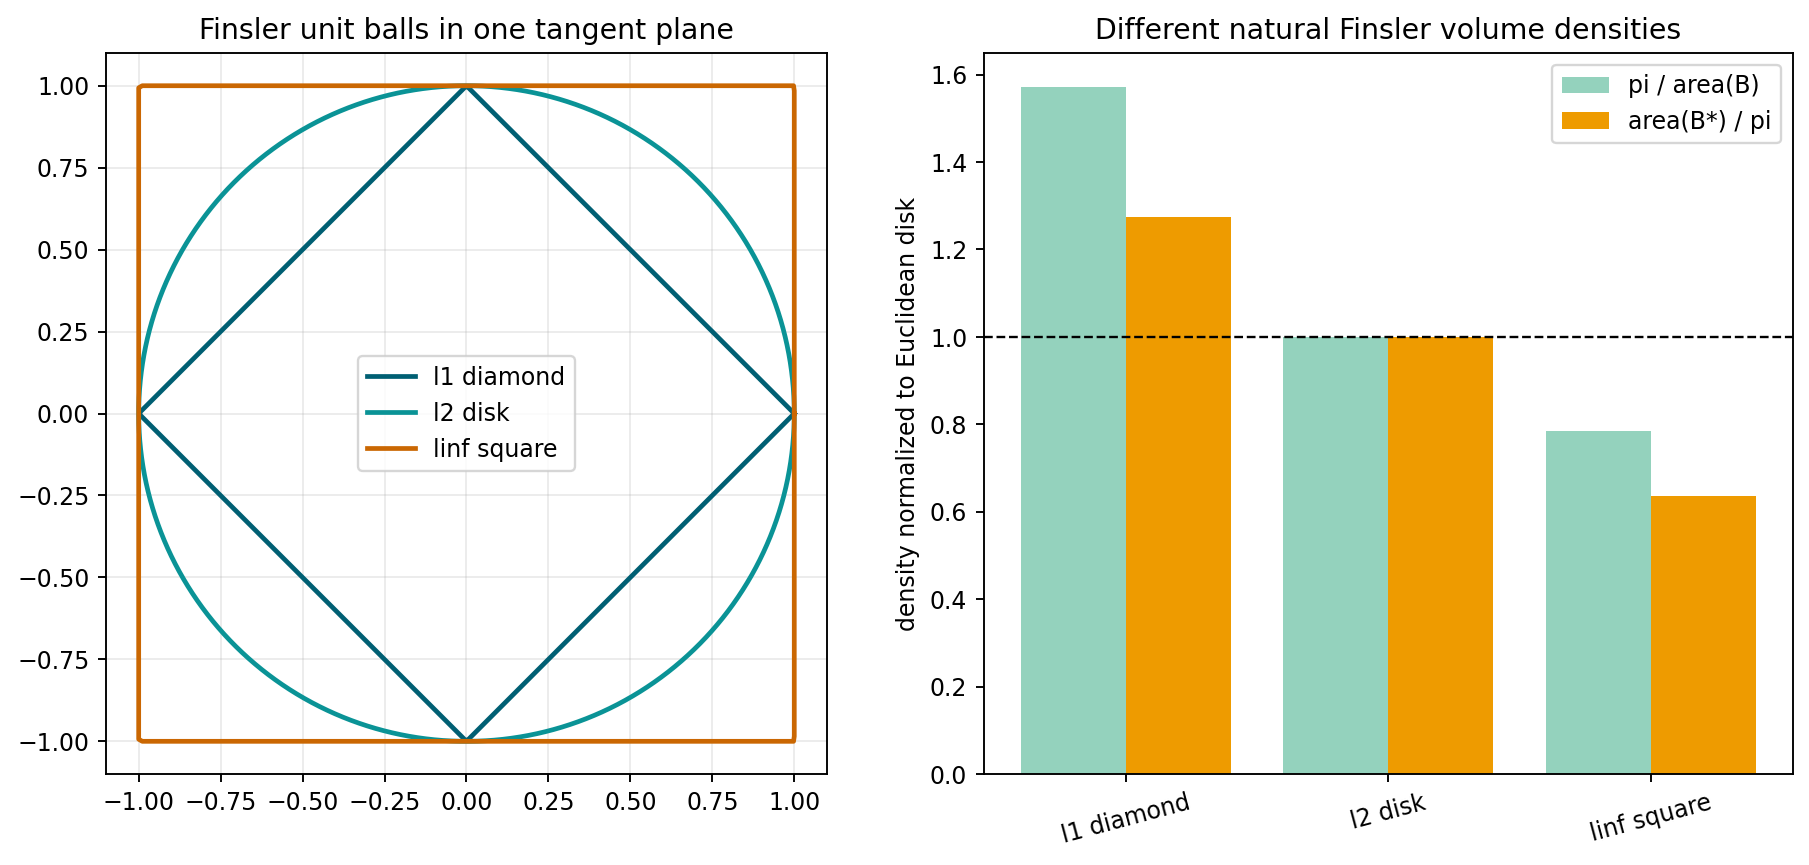

,norm,unit_ball_area,polar_unit_ball_area,busemann_density_pi_over_area,holmes_thompson_density_polar_over_pi
0,l1 diamond,2.000000,4.000000,1.570796,1.27324
1,l2 disk,3.141593,3.141593,1.000000,1.00000
2,linf square,4.000000,2.000000,0.785398,0.63662


In [6]:
def lp_boundary(p, n=720):
    theta = np.linspace(0, 2*np.pi, n, endpoint=True)
    c, s = np.cos(theta), np.sin(theta)
    scale = 1 / np.maximum(abs(c), abs(s)) if p == np.inf else 1 / (abs(c)**p + abs(s)**p)**(1/p)
    return scale*c, scale*s

def lp_ball_area(p):
    if p == 1: return 2.0
    if p == 2: return math.pi
    if p == np.inf: return 4.0
    theta = np.linspace(0, 2*np.pi, 20000)
    r = 1 / (abs(np.cos(theta))**p + abs(np.sin(theta))**p)**(1/p)
    return float(0.5 * np.trapezoid(r*r, theta))

norm_rows = []
for label, p, polar_p in [('l1 diamond', 1, np.inf), ('l2 disk', 2, 2), ('linf square', np.inf, 1)]:
    area = lp_ball_area(p); polar_area = lp_ball_area(polar_p)
    norm_rows.append({'norm': label, 'unit_ball_area': area, 'polar_unit_ball_area': polar_area, 'busemann_density_pi_over_area': math.pi / area, 'holmes_thompson_density_polar_over_pi': polar_area / math.pi})
volume_table = pd.DataFrame(norm_rows)
table_path = TABLE_DIR / 'finsler-volume-table.csv'
volume_table.to_csv(table_path, index=False)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 5.2))
colors = {'l1 diamond':'#005f73', 'l2 disk':'#0a9396', 'linf square':'#ca6702'}
for row, p in zip(norm_rows, [1, 2, np.inf]):
    x, y = lp_boundary(p)
    axes[0].plot(x, y, color=colors[row['norm']], lw=2, label=row['norm'])
axes[0].set_title('Finsler unit balls in one tangent plane')
axes[0].set_aspect('equal', adjustable='box')
axes[0].grid(alpha=0.25); axes[0].legend()
bar_x = np.arange(len(volume_table))
axes[1].bar(bar_x - 0.2, volume_table['busemann_density_pi_over_area'], width=0.4, label='pi / area(B)', color='#94d2bd')
axes[1].bar(bar_x + 0.2, volume_table['holmes_thompson_density_polar_over_pi'], width=0.4, label='area(B*) / pi', color='#ee9b00')
axes[1].axhline(1.0, color='black', lw=1, ls='--')
axes[1].set_xticks(bar_x); axes[1].set_xticklabels(volume_table['norm'], rotation=15)
axes[1].set_title('Different natural Finsler volume densities')
axes[1].set_ylabel('density normalized to Euclidean disk')
axes[1].legend()
fig.tight_layout()
fig_path = save_matplotlib(fig, FIG_DIR / 'volume-comparison.png')

xgrid = np.linspace(-1, 1, 180); ygrid = np.linspace(-1, 1, 180)
DX = xgrid[1] - xgrid[0]; DY = ygrid[1] - ygrid[0]
riemannian_area = 0.0
for x in xgrid:
    for y in ygrid:
        riemannian_area += math.sqrt(np.linalg.det(metric_matrix(x, y))) * DX * DY
check_path = write_json(CHECK_DIR / 'volume-comparison-checks.json', {
    'figure': rel(fig_path),
    'table': rel(table_path),
    'riemannian_area_density_integral_on_square': riemannian_area,
    'euclidean_square_area': 4.0,
    'finsler_density_rows': norm_rows,
    'l2_busemann_density_error': abs(float(volume_table.loc[volume_table['norm']=='l2 disk','busemann_density_pi_over_area'].iloc[0]) - 1.0),
    'l2_holmes_thompson_density_error': abs(float(volume_table.loc[volume_table['norm']=='l2 disk','holmes_thompson_density_polar_over_pi'].iloc[0]) - 1.0),
})
display_artifact(fig_path)
volume_table


## 6. Besikovitch Inequality: Face Distances Force Volume

Besikovitch's inequality is deliberately curvature-free. For a Riemannian metric on the cube, let `d_i` be the distance between the two opposite faces perpendicular to the `i`th coordinate. The theorem says the volume is at least the product of those face distances.

The code uses a transparent two-dimensional metric on the square: `ds^2 = A(y)^2 dx^2 + B(x)^2 dy^2`. The distance between left and right faces is at least `min A`, and the distance between bottom and top faces is at least `min B`; the area is the integral of `A(y)B(x)`. This example does not prove the theorem, but it gives a checkable model of the inequality. A second artifact records the proof dependency: distance-to-face functions are nonexpanding, their map respects faces, the boundary behavior gives degree one, degree one forces the parallelotope to be covered, and the Jacobian estimate gives the volume lower bound.


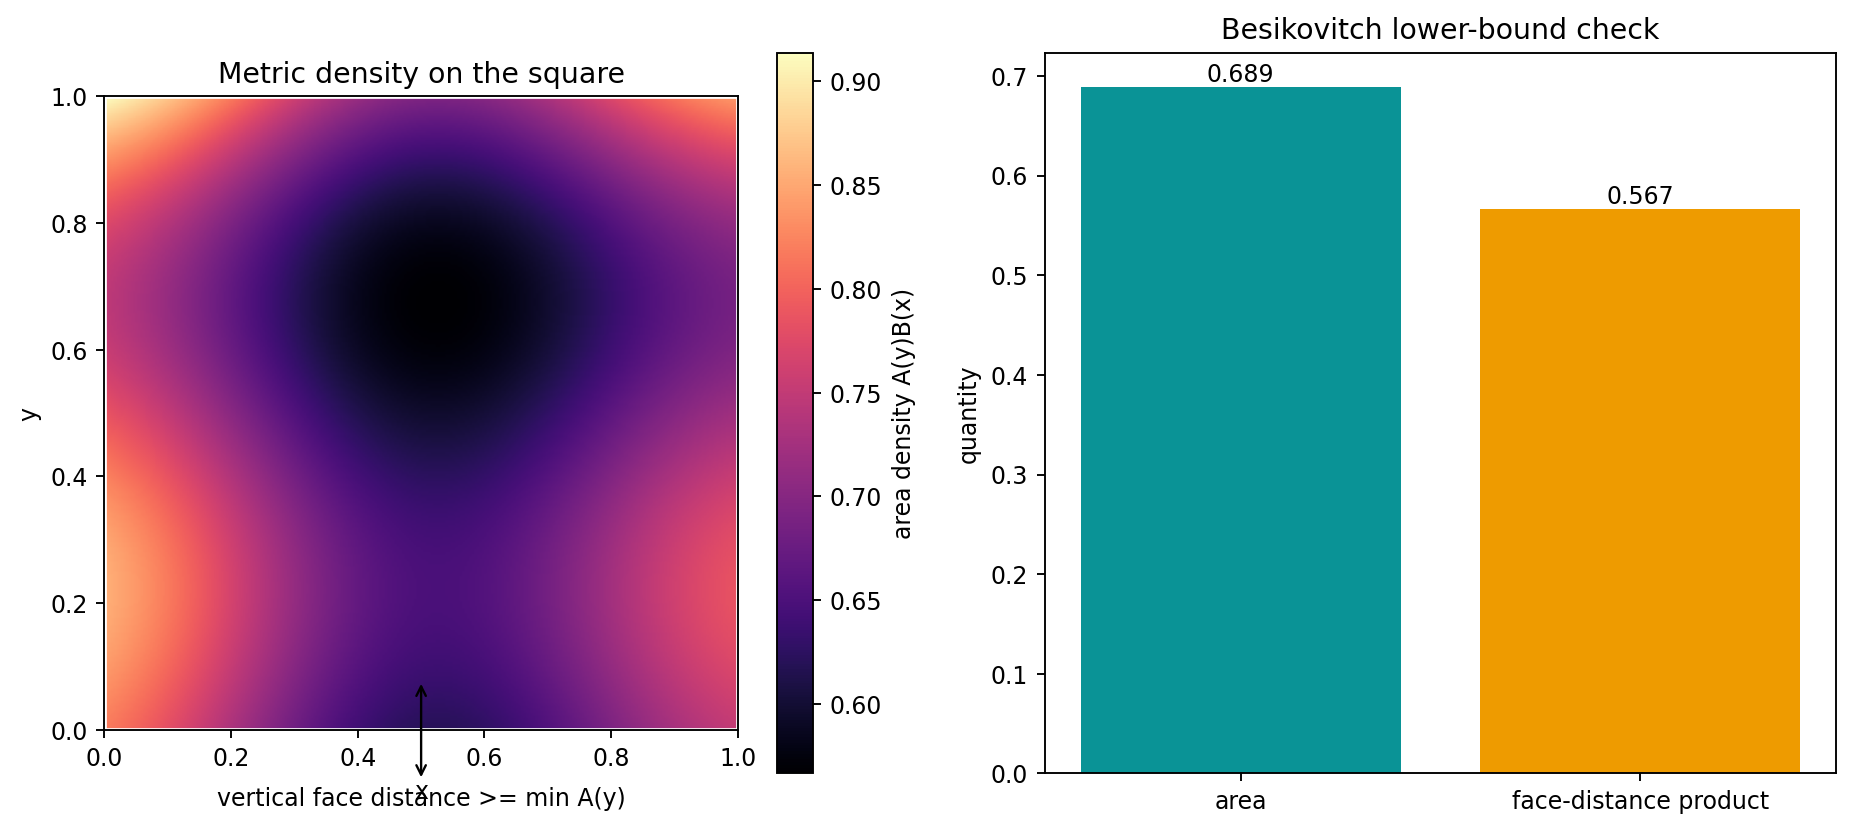

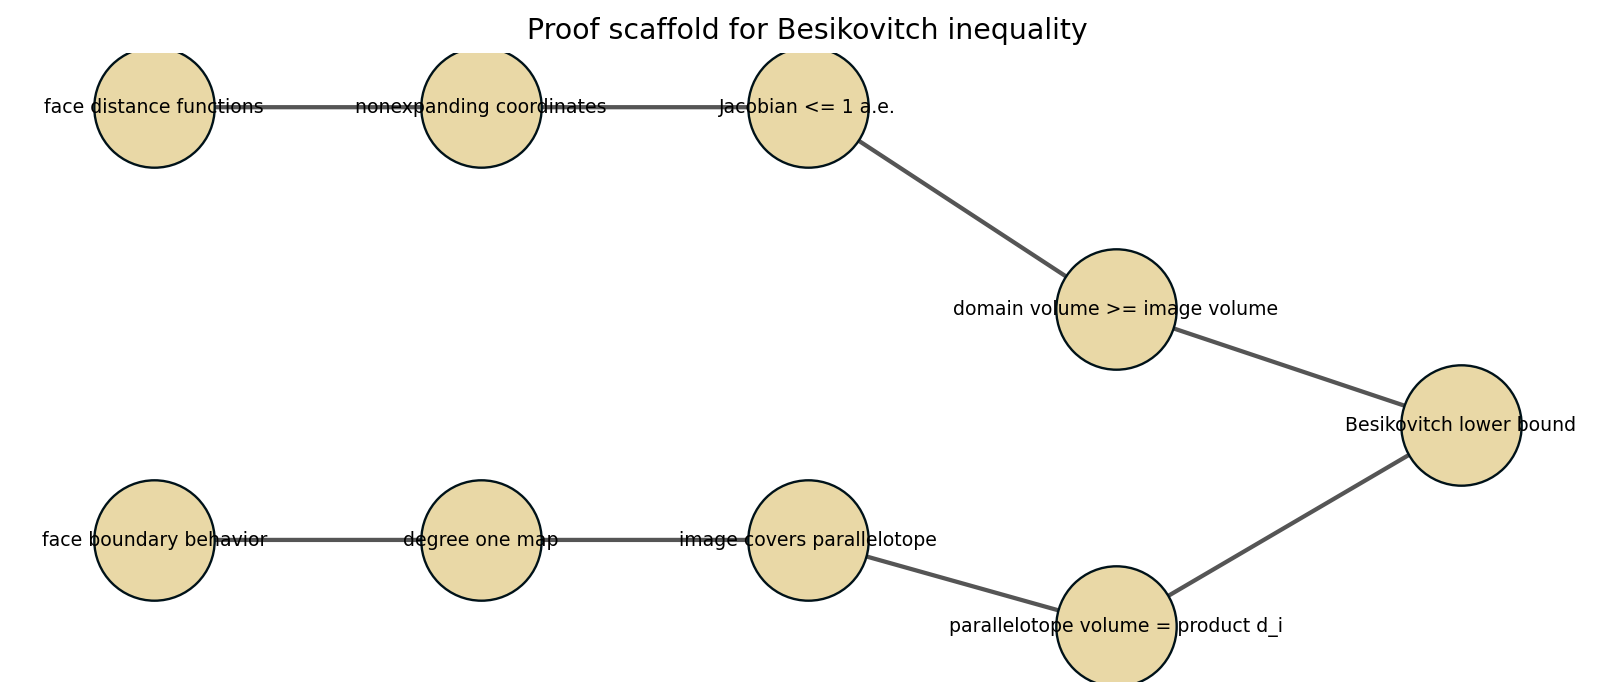

{'area_integral': 0.6887521202791285,
 'area_minus_product_bound': 0.12213845029287929,
 'cube_map_figure': 'artifacts/chapter-05/figures/besikovitch-cube-map.png',
 'distance_between_horizontal_faces_lower_bound': 0.694644622483584,
 'distance_between_vertical_faces_lower_bound': 0.8156885573524173,
 'inequality_verified_for_model': True,
 'product_of_face_distance_lower_bounds': 0.5666136699862492,
 'proof_dependency_figure': 'artifacts/chapter-05/figures/besikovitch-proof-dependency.png',
 'proof_graph_edges': [['face distance functions', 'nonexpanding coordinates'],
  ['nonexpanding coordinates', 'Jacobian <= 1 a.e.'],
  ['face boundary behavior', 'degree one map'],
  ['degree one map', 'image covers parallelotope'],
  ['image covers parallelotope', 'parallelotope volume = product d_i'],
  ['Jacobian <= 1 a.e.', 'domain volume >= image volume'],
  ['domain volume >= image volume', 'Besikovitch lower bound'],
  ['parallelotope volume = product d_i', 'Besikovitch lower bound']]}

In [7]:
def A_y(y):
    return 0.85 + 0.35*(y - 0.35)**2 + 0.08*np.sin(2*np.pi*y)

def B_x(x):
    return 0.75 + 0.25*(x - 0.65)**2 + 0.06*np.cos(2*np.pi*x)

n = 260
xs = np.linspace(0, 1, n); ys = np.linspace(0, 1, n)
X, Y = np.meshgrid(xs, ys)
density = A_y(Y) * B_x(X)
area = float(np.trapezoid(np.trapezoid(density, xs, axis=1), ys))
dx_faces = float(np.min(A_y(ys))); dy_faces = float(np.min(B_x(xs)))
product_bound = dx_faces * dy_faces

fig, axes = plt.subplots(1, 2, figsize=(11.0, 5.0))
im = axes[0].imshow(density, extent=[0,1,0,1], origin='lower', cmap='magma')
fig.colorbar(im, ax=axes[0], label='area density A(y)B(x)')
axes[0].set_title('Metric density on the square')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].add_patch(Rectangle((0,0), 1, 1, fill=False, ec='white', lw=2))
axes[0].annotate('vertical face distance >= min A(y)', xy=(0.5,0.08), xytext=(0.5,-0.12), ha='center', arrowprops=dict(arrowstyle='<->'))
axes[1].bar(['area', 'face-distance product'], [area, product_bound], color=['#0a9396', '#ee9b00'])
axes[1].set_title('Besikovitch lower-bound check')
axes[1].set_ylabel('quantity')
axes[1].text(0, area, f'{area:.3f}', ha='center', va='bottom')
axes[1].text(1, product_bound, f'{product_bound:.3f}', ha='center', va='bottom')
fig.tight_layout()
fig_path = save_matplotlib(fig, FIG_DIR / 'besikovitch-cube-map.png')

Gproof = nx.DiGraph()
proof_edges = [
    ('face distance functions', 'nonexpanding coordinates'),
    ('nonexpanding coordinates', 'Jacobian <= 1 a.e.'),
    ('face boundary behavior', 'degree one map'),
    ('degree one map', 'image covers parallelotope'),
    ('image covers parallelotope', 'parallelotope volume = product d_i'),
    ('Jacobian <= 1 a.e.', 'domain volume >= image volume'),
    ('domain volume >= image volume', 'Besikovitch lower bound'),
    ('parallelotope volume = product d_i', 'Besikovitch lower bound'),
]
Gproof.add_edges_from(proof_edges)
pos = {
    'face distance functions': (0, 2), 'nonexpanding coordinates': (1.8, 2), 'Jacobian <= 1 a.e.': (3.6, 2),
    'domain volume >= image volume': (5.3, 1.3), 'face boundary behavior': (0, 0.5), 'degree one map': (1.8, 0.5),
    'image covers parallelotope': (3.6, 0.5), 'parallelotope volume = product d_i': (5.3, 0.2),
    'Besikovitch lower bound': (7.2, 0.9),
}
fig2, ax2 = plt.subplots(figsize=(12, 4.8))
nx.draw_networkx_edges(Gproof, pos, ax=ax2, arrows=True, arrowstyle='-|>', arrowsize=16, width=1.8, edge_color='#555')
nx.draw_networkx_nodes(Gproof, pos, ax=ax2, node_size=2600, node_color='#e9d8a6', edgecolors='#001219')
nx.draw_networkx_labels(Gproof, pos, ax=ax2, font_size=8)
ax2.set_title('Proof scaffold for Besikovitch inequality')
ax2.axis('off')
proof_path = save_matplotlib(fig2, FIG_DIR / 'besikovitch-proof-dependency.png')
check_path = write_json(CHECK_DIR / 'besikovitch-checks.json', {
    'cube_map_figure': rel(fig_path),
    'proof_dependency_figure': rel(proof_path),
    'area_integral': area,
    'distance_between_vertical_faces_lower_bound': dx_faces,
    'distance_between_horizontal_faces_lower_bound': dy_faces,
    'product_of_face_distance_lower_bounds': product_bound,
    'area_minus_product_bound': area - product_bound,
    'inequality_verified_for_model': bool(area + 1e-12 >= product_bound),
    'proof_graph_edges': proof_edges,
})
display_artifact(fig_path)
display_artifact(proof_path)
json.loads(check_path.read_text(encoding='utf-8'))


## Applied Lab: Reading The Chapter Through Computations

Use the generated artifacts as a sequence of questions. In the metric-tensor figure, choose one ellipse and identify which tangent directions are cheap or expensive. In the exponential-map figure, follow one ray and one wavefront; the ray records a fixed initial direction, while the wavefront records a fixed travel time. In the hyperbolic lab, inspect a geodesic arc near the ideal boundary and remember that its Euclidean shape is not the intrinsic message. In the sub-Riemannian figure, explain why the vertical axis is visible even though neither allowed vector field points vertically. In the volume table, compare `l1` and `linf`; their unit balls are polar to each other, so different Finsler volume choices exchange what looks large and what looks small. In the Besikovitch proof graph, find the topological ingredient: degree prevents the distance-to-face map from avoiding the whole target parallelotope.


In [8]:
source_coverage = {
    'source_span': SOURCE_SPAN,
    'implemented_storyboard': [
        {'section': '5.1', 'concept': 'Riemannian metric coefficients and length integration', 'representation': 'density field, tangent-unit ellipses, sampled curve', 'artifacts': [rel(FIG_DIR / 'metric-tensor-length-field.png'), rel(CHECK_DIR / 'metric-length-checks.json')], 'validation': 'positive definiteness on grid and finite curve length ratio'},
        {'section': '5.2', 'concept': 'exponential map and normal coordinates', 'representation': 'sphere exponential map rays and wavefronts', 'artifacts': [rel(FIG_DIR / 'exponential-map-normal-coordinates.png'), rel(CHECK_DIR / 'exponential-map-checks.json')], 'validation': 'unit endpoint norm and radial/angular orthogonality residual'},
        {'section': '5.3', 'concept': 'Poincare hyperbolic plane', 'representation': 'interactive disk geodesics, horocycles, ideal boundary', 'artifacts': [rel(HTML_DIR / 'hyperbolic-poincare-lab.html'), rel(CHECK_DIR / 'hyperbolic-model-checks.json')], 'validation': 'disk distance invariant under sampled isometry'},
        {'section': '5.4', 'concept': 'sub-Riemannian horizontal curves and brackets', 'representation': 'commutator endpoints and ball-box scaling', 'artifacts': [rel(FIG_DIR / 'sub-riemannian-ball-box.png'), rel(CHECK_DIR / 'sub-riemannian-checks.json')], 'validation': 'commutator vertical displacement equals u*v'},
        {'section': '5.5', 'concept': 'Riemannian and Finsler volume functionals', 'representation': 'norm unit balls, density bars, CSV table', 'artifacts': [rel(FIG_DIR / 'volume-comparison.png'), rel(TABLE_DIR / 'finsler-volume-table.csv'), rel(CHECK_DIR / 'volume-comparison-checks.json')], 'validation': 'Euclidean l2 normalization equals one for two density formulas'},
        {'section': '5.6', 'concept': 'Besikovitch inequality', 'representation': 'warped-square model and proof dependency graph', 'artifacts': [rel(FIG_DIR / 'besikovitch-cube-map.png'), rel(FIG_DIR / 'besikovitch-proof-dependency.png'), rel(CHECK_DIR / 'besikovitch-checks.json')], 'validation': 'area integral exceeds product of face-distance lower bounds'},
    ],
    'copyright_note': 'No textbook prose, long exercise text, screenshots, page crops, or source figures are copied.',
}
storyboard_path = write_json(CHECK_DIR / 'visual-storyboard.json', {
    'chapter_goal': 'Build smooth length structures from tangent norms through geodesics, hyperbolic models, sub-Riemannian reachability, volume, and Besikovitch lower bounds.',
    'visual_sequence': source_coverage['implemented_storyboard'],
    'source_span': SOURCE_SPAN,
})
coverage_path = write_json(CHECK_DIR / 'source-coverage.json', source_coverage)
source_coverage


{'source_span': {'chapter': '05 Smooth Length Structures',
  'printed_pages': '135-208',
  'pdf_pages': '150-223',
  'sections': {'5.1': 'Riemannian Length Structures',
   '5.2': 'Exponential Map',
   '5.3': 'Hyperbolic Plane',
   '5.4': 'Sub-Riemannian Metric Structures',
   '5.5': 'Riemannian and Finsler Volumes',
   '5.6': 'Besikovitch Inequality'},
  'source_use': 'orientation, terminology, section order, and theorem targets only'},
 'implemented_storyboard': [{'section': '5.1',
   'concept': 'Riemannian metric coefficients and length integration',
   'representation': 'density field, tangent-unit ellipses, sampled curve',
   'artifacts': ['artifacts/chapter-05/figures/metric-tensor-length-field.png',
    'artifacts/chapter-05/checks/metric-length-checks.json'],
   'validation': 'positive definiteness on grid and finite curve length ratio'},
  {'section': '5.2',
   'concept': 'exponential map and normal coordinates',
   'representation': 'sphere exponential map rays and wavefronts'

## Final Sanity Checks

The final cell asserts three kinds of contract: every named artifact exists and has nontrivial size; every PNG has nonzero grayscale variation, so blank figures fail fast; and every mathematical check used in the chapter is within its stated tolerance. These checks do not prove the chapter's theorems, but they keep the notebook honest: the visuals are generated, the invariants are computed, and the source coverage record names which artifact teaches which section.


In [9]:
expected_artifacts = [
    FIG_DIR / 'metric-tensor-length-field.png',
    FIG_DIR / 'exponential-map-normal-coordinates.png',
    HTML_DIR / 'hyperbolic-poincare-lab.html',
    FIG_DIR / 'sub-riemannian-ball-box.png',
    FIG_DIR / 'volume-comparison.png',
    TABLE_DIR / 'finsler-volume-table.csv',
    FIG_DIR / 'besikovitch-cube-map.png',
    FIG_DIR / 'besikovitch-proof-dependency.png',
    CHECK_DIR / 'metric-length-checks.json',
    CHECK_DIR / 'exponential-map-checks.json',
    CHECK_DIR / 'hyperbolic-model-checks.json',
    CHECK_DIR / 'sub-riemannian-checks.json',
    CHECK_DIR / 'volume-comparison-checks.json',
    CHECK_DIR / 'besikovitch-checks.json',
    CHECK_DIR / 'source-coverage.json',
    CHECK_DIR / 'visual-storyboard.json',
]
artifact_records = []
for path in expected_artifacts:
    assert path.exists(), f'missing artifact: {path}'
    size = path.stat().st_size
    assert size > 80, f'artifact too small: {path}'
    record = {'path': rel(path), 'bytes': size}
    if path.suffix.lower() == '.png':
        stats = image_stats(path)
        assert stats['stddev'] > 1.0, f'blank-looking image: {path}'
        record.update(stats)
    artifact_records.append(record)

metric_checks = json.loads((CHECK_DIR / 'metric-length-checks.json').read_text(encoding='utf-8'))
exp_checks = json.loads((CHECK_DIR / 'exponential-map-checks.json').read_text(encoding='utf-8'))
hyp_checks = json.loads((CHECK_DIR / 'hyperbolic-model-checks.json').read_text(encoding='utf-8'))
sr_checks = json.loads((CHECK_DIR / 'sub-riemannian-checks.json').read_text(encoding='utf-8'))
vol_checks = json.loads((CHECK_DIR / 'volume-comparison-checks.json').read_text(encoding='utf-8'))
bes_checks = json.loads((CHECK_DIR / 'besikovitch-checks.json').read_text(encoding='utf-8'))
assert metric_checks['positive_definite_on_grid']
assert metric_checks['riemannian_length'] > 0
assert exp_checks['max_radial_angular_dot_product'] < 1e-12
assert exp_checks['max_endpoint_unit_sphere_error'] < 1e-12
assert hyp_checks['distance_invariance_error'] < 1e-12
assert hyp_checks['max_radial_distance_formula_error'] < 1e-12
assert sr_checks['vertical_error_against_u_times_v'] < 1e-12
assert vol_checks['l2_busemann_density_error'] < 1e-12
assert vol_checks['l2_holmes_thompson_density_error'] < 1e-12
assert bes_checks['inequality_verified_for_model']
assert bes_checks['area_minus_product_bound'] >= -1e-12
final_sanity = {
    'source_span': SOURCE_SPAN,
    'artifact_count': len(artifact_records),
    'artifacts': artifact_records,
    'checks': {
        'metric_positive_definite': metric_checks['positive_definite_on_grid'],
        'exponential_gauss_orthogonality_residual': exp_checks['max_radial_angular_dot_product'],
        'hyperbolic_distance_invariance_error': hyp_checks['distance_invariance_error'],
        'sub_riemannian_commutator_error': sr_checks['vertical_error_against_u_times_v'],
        'finsler_l2_density_errors': [vol_checks['l2_busemann_density_error'], vol_checks['l2_holmes_thompson_density_error']],
        'besikovitch_area_minus_product_bound': bes_checks['area_minus_product_bound'],
    },
    'standalone_contract': True,
}
final_path = write_json(CHECK_DIR / 'final-sanity.json', final_sanity)
final_sanity


{'source_span': {'chapter': '05 Smooth Length Structures',
  'printed_pages': '135-208',
  'pdf_pages': '150-223',
  'sections': {'5.1': 'Riemannian Length Structures',
   '5.2': 'Exponential Map',
   '5.3': 'Hyperbolic Plane',
   '5.4': 'Sub-Riemannian Metric Structures',
   '5.5': 'Riemannian and Finsler Volumes',
   '5.6': 'Besikovitch Inequality'},
  'source_use': 'orientation, terminology, section order, and theorem targets only'},
 'artifact_count': 16,
 'artifacts': [{'path': 'artifacts/chapter-05/figures/metric-tensor-length-field.png',
   'bytes': 135040,
   'size': [1231, 808],
   'mean': 207.47607595853006,
   'stddev': 66.39855249799531},
  {'path': 'artifacts/chapter-05/figures/exponential-map-normal-coordinates.png',
   'bytes': 195019,
   'size': [1027, 1012],
   'mean': 248.71034345401435,
   'stddev': 24.929748903649042},
  {'path': 'artifacts/chapter-05/html/hyperbolic-poincare-lab.html',
   'bytes': 106703},
  {'path': 'artifacts/chapter-05/figures/sub-riemannian-bal

## Takeaways

- A Riemannian metric is a smoothly varying tangent norm whose integrated curve lengths define an intrinsic metric.
- The exponential map turns initial velocities into geodesic coordinates; normal-coordinate wavefronts expose the Gauss-lemma orthogonality pattern.
- The Poincare models are faithful hyperbolic models only when hyperbolic length, area, distance, and isometry rules are used instead of Euclidean visual guesses.
- Sub-Riemannian metrics demonstrate that changing the admissible curves can change the small-scale geometry more radically than merely changing the cost of all directions.
- Riemannian volume is forced by monotonicity and Euclidean compatibility, while Finsler volume admits several natural choices tied to convex bodies and their polars.
- Besikovitch's inequality is a metric-volume statement with a topological lock: degree prevents the distance-to-face map from avoiding the whole target box.
